17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
X_train shape: (25000, 200)
X_test shape: (25000, 200)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.4985 - loss: 0.7043 - val_accuracy: 0.4962 - val_loss: 0.6947
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.5811 - loss: 0.6676 - val_accuracy: 0.5040 - val_loss: 0.7008
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6826 - loss: 0.5443 - val_accuracy: 0.4998 - val_loss: 0.7743
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7442 - loss: 0.4269 - val_accuracy: 0.4948 - val_loss: 0.8775
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7685 - loss: 0.3793 - val_accuracy: 0.5082 - val_loss: 0.9096
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5075 - loss: 0.9173

Test Loss: 0.9173304438591003
Test Accuracy: 0.5075200200080872


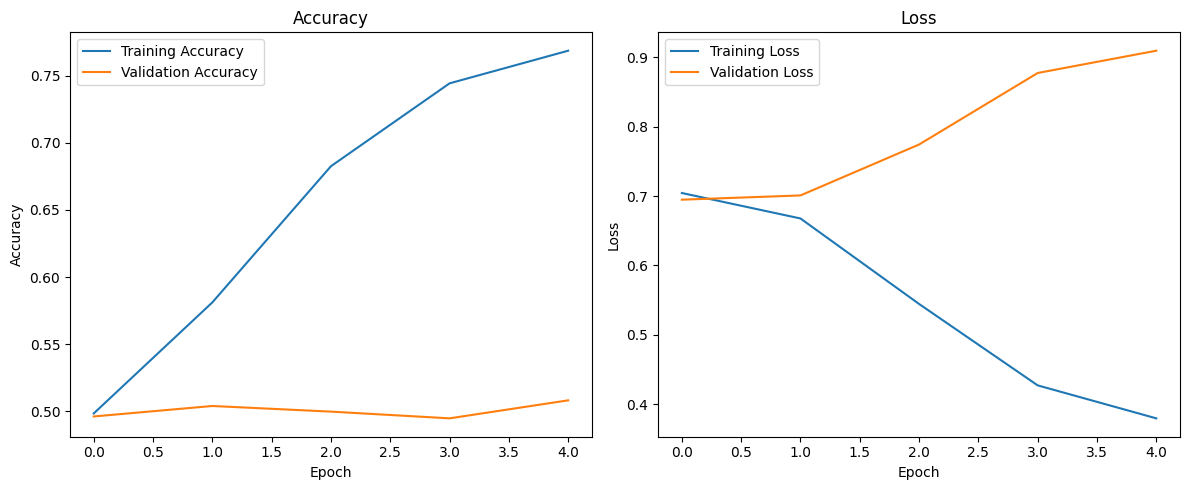

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step

Review: 
This movie was absolutely fantastic.
The acting was excellent and the story was very entertaining.

Sentiment Score: 0.56844413
Prediction: POSITIVE


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout


# -----------------------------------
# 1. Parameters
# -----------------------------------

vocab_size = 10000
max_length = 200


# -----------------------------------
# 2. Load IMDB dataset
# -----------------------------------

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# -----------------------------------
# 3. Pad sequences
# -----------------------------------

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


# -----------------------------------
# 4. Build RNN model
# -----------------------------------

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


# -----------------------------------
# 5. Compile model
# -----------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# -----------------------------------
# 6. Train model
# -----------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


# -----------------------------------
# 7. Evaluate model
# -----------------------------------

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# -----------------------------------
# 8. Plot results
# -----------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# -----------------------------------
# 9. Predict new review
# -----------------------------------

word_index = imdb.get_word_index()


def encode_review(text):

    words = text.lower().split()
    encoded = []

    for word in words:

        index = word_index.get(word, 2) + 3

        if index >= vocab_size:
            index = 2

        encoded.append(index)

    return pad_sequences(
        [encoded],
        maxlen=max_length,
        padding='post',
        truncating='post'
    )


review = """
This movie was absolutely fantastic.
The acting was excellent and the story was very entertaining.
"""

encoded_review = encode_review(review)

prediction = model.predict(encoded_review)[0][0]

print("\nReview:", review)
print("Sentiment Score:", prediction)

if prediction >= 0.5:
    print("Prediction: POSITIVE")
else:
    print("Prediction: NEGATIVE")
